In [468]:
import sys
import os

# Option A: Use a relative path (e.g., up one directory level)
sys.path.insert(0, os.path.abspath('..'))


### Repository Structure

The primary data structures used in this notebook are defined in the `analysis` package:

- `PairDistanceData` — stores and processes pairwise distance matrices.
- `SVDAnalysis` — encapsulates the Singular Value Decomposition (SVD) results, reduced state-space representation, explained variance, and reconstruction utilities.

Both data classes are implemented in `analysis/types.py`.

For the complete source code and ongoing updates, please visit the project repository:

**GitHub:** https://github.com/panda-yoo/droplet-simulation

```python
"""
analysis.types
==============
Shared type aliases used across the analysis package.
"""

from numpy.typing import NDArray
import numpy as np
from dataclasses import dataclass,field

from typing import Dict, Optional, Tuple
from functools import cached_property

# Canonical position dict type: droplet_id -> (N, 2) float array
PositionsDict = Dict[int, NDArray[np.floating]]

@dataclass(slots=True)
class PairDistanceData:
    distances: NDArray[np.float64]
    pair_map: list[tuple[int, int]]
    
    # default=None -> means take default as None type
    # init=False -> dont intialize when a object is initilaized i.e init is called 
    _mean: Optional[NDArray[np.float64]] = field(default=None, init=False)
    _std: Optional[NDArray[np.float64]] = field(default=None, init=False)

    @property
    def npairs(self) -> int:
        return len(self.pair_map)

    @property
    def nframes(self) -> int:
        return self.distances.shape[0]
    
    def pair(self, k: int) -> tuple[int, int]:
        return self.pair_map[k]

    @property
    def mean(self):
        if self._mean is None:
            self._mean = self.distances.mean(axis=0)
        return self._mean


    @property
    def std(self)->NDArray[np.float64]:
        if self._std is None:
            self._std = self.distances.std(axis=0)
            
            # self._std[self._std == 0] = 1.0
            eps = np.finfo(np.float64).eps
            self._std = np.maximum(self._std, eps)
            
        return self._std

    def standardized(self) -> NDArray[np.float64]:
        return np.asarray(
            (self.distances - self.mean) / self.std,
            dtype=np.float64
        )
    
    def destandardize(self, x: NDArray[np.float64]) -> NDArray[np.float64]:
        """
        Convert standardized pair distances back to physical units.
        """
        return x * self.std + self.mean

    def distance_change(self, dz: NDArray[np.float64]) -> NDArray[np.float64]:
        """
        Convert standardized distance changes into physical distance changes.
        """
        return dz * self.std


@dataclass
class SVDAnalysis:
    
    # Original data
    data: NDArray[np.float64]
    # SVD decomposition
    U: NDArray[np.float64]
    S: NDArray[np.float64]
    VT: NDArray[np.float64]
    
    # Metadata
    n_modes: int = 3
    
    # Low-dimensional representation
    @cached_property
    def scores(self)->NDArray[np.float64]:
        """scalar multiplication of vectors u with sigma eigenvalues  

        Returns:
            NDArray[np.float64]: _description_
        """
        return self.S * self.U 
         
    @cached_property
    def reduced_scores(self)->NDArray[np.float64]:
        return self.scores[:,:self.n_modes]
    
    @cached_property
    def explained_variance(self):
        return self.S**2 / np.sum(self.S**2)
        
    @cached_property
    def cumulative_variance(self):
        return np.cumsum(self.explained_variance)
    
    @cached_property
    def reconstruct(self):
        return (self.U[:,:self.n_modes] 
                @ np.diag(self.S[:self.n_modes])
                @ self.VT[:self.n_modes])
    
```

In [500]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
import pandas as pd

In [470]:
from analysis.types import PositionsDict,PairDistanceData
from analysis.extract import load_positions   
from analysis.pairwise import compute_inter_distance_squared

In [471]:
trajectories,*_ = load_positions('../output_droplet_tracking/csv_files/for_2.3_droplets.csv')
p = compute_inter_distance_squared(trajectories=trajectories)

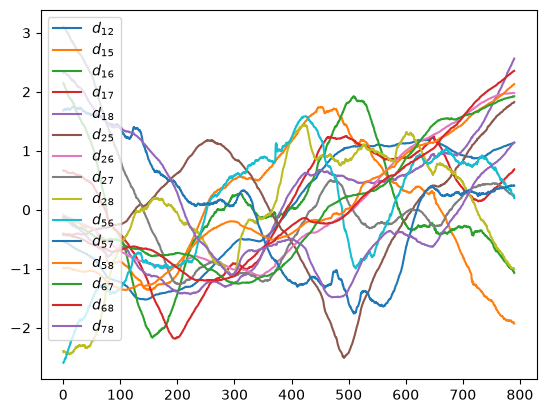

In [472]:
def dij_telda(dijs :PairDistanceData):
    
    m = np.zeros(shape=(dijs.nframes,dijs.npairs))
    
    for i in range(dijs.npairs):
        dij = dijs.distances[:,i]
        dij_mean = np.mean(dij)
        dij_std = np.std(dij)
        # dij_var = np.var(dij)
        m[:,i] = (dij - dij_mean)/dij_std
        
    return m 
        
        
dtelda = dij_telda(p)
        
t = [.2*i for i in range(p.nframes)]

for i in range(p.npairs):
    
    map = p.pair_map
    plt.plot(t,dtelda[:,i],
             label=fr'$d_{str(map[i][0])}$$_{str(map[i][1])}$')
    
    
plt.legend()
# .2*list(range(12))


mean = 251.23657181014667 varience = 17459.901019375033
mean = 324.06973191240127 varience = 3473.3712633114674
mean = 146.75399249158028 varience = 1653.2922691972528
mean = 191.3275427641535 varience = 5697.845851466438
mean = 264.84599667059996 varience = 5481.341766409459
mean = 209.70681110395512 varience = 5387.127308547634
mean = 203.73824536157676 varience = 20298.344524359058
mean = 153.13957426526804 varience = 2264.659940478609
mean = 155.7163155056618 varience = 726.7214991851024
mean = 214.5391042702803 varience = 832.8474203336292
mean = 235.92966068593418 varience = 989.6973175495378
mean = 206.05375156444467 varience = 12816.876575281454
mean = 160.2288798967737 varience = 8238.872369613066
mean = 222.39075122890122 varience = 19412.767612419033
mean = 134.19203849265543 varience = 5307.6212922083905


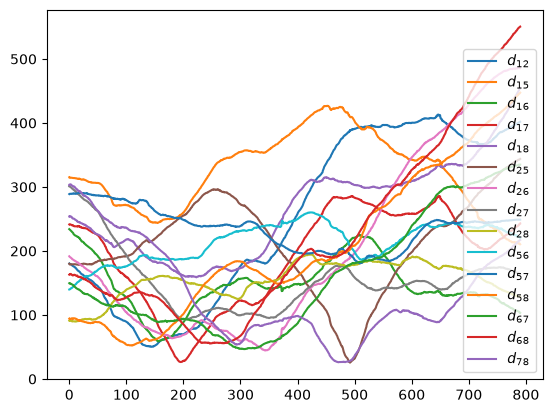

In [473]:
dij = p.distances[:,0]

t = [.2*i for i in range(p.nframes)]

for i in range(p.npairs):
    
    map = p.pair_map
    plt.plot(t,p.distances[:,i],
             label=fr'$d_{str(map[i][0])}$$_{str(map[i][1])}$')
    
        
    dij_mean = np.mean(p.distances[:,i])
    dij_var = np.var(p.distances[:,i])
    
    print("mean = "+ str(dij_mean)+" "+"varience = " + str(dij_var))
plt.legend()
# .2*list(range(12))

In [474]:
pstandard = p.standardized()

In [475]:
U,S,VT = np.linalg.svd(pstandard,full_matrices=False)

In [476]:
U.shape,S.shape,VT.shape

((3951, 15), (15,), (15, 15))

In [477]:
S

array([163.32040581, 127.41405501, 104.4276841 ,  51.51214304,
        39.02794631,  25.63805408,  15.10099268,  12.51588935,
        10.57557348,   7.84458436,   5.22264658,   4.86815892,
         2.12180177,   1.6939364 ,   1.24777328])

In [478]:
coords = U[:, :3] * S[:3]
coords

array([[-2.15188814, -2.68182948, -4.9132514 ],
       [-2.16268632, -2.68881117, -4.91793185],
       [-2.16470756, -2.69347224, -4.91831583],
       ...,
       [ 3.49442229, -4.58309424,  1.22223587],
       [ 3.49366972, -4.5883777 ,  1.22197553],
       [ 3.49282642, -4.59285369,  1.22180905]], shape=(3951, 3))

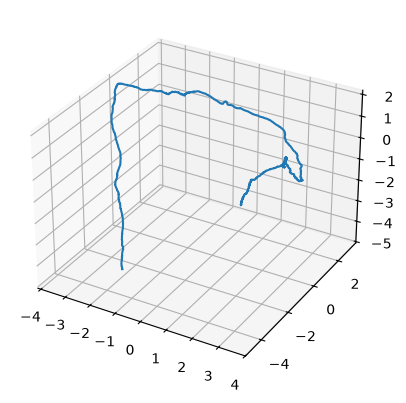

In [479]:
ax = plt.subplot(projection='3d')
ax.plot(coords[:,0],coords[:,1],coords[:,2])

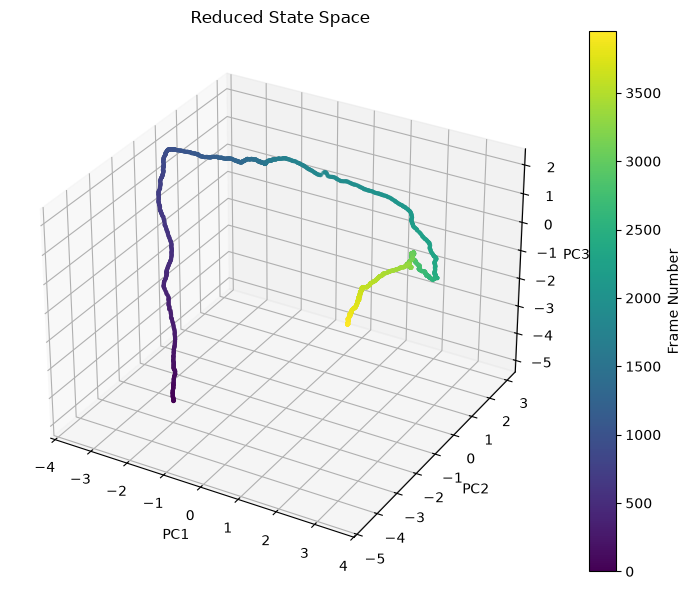

In [480]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(projection='3d')

t = np.arange(coords.shape[0])

p = ax.scatter(
    coords[:,0],
    coords[:,1],
    coords[:,2],
    c=t,
    cmap='viridis',
    s=4
)

ax.plot(
    coords[:,0],
    coords[:,1],
    coords[:,2],
    color='gray',
    alpha=0.3,
    lw=0.8
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

ax.set_title('Reduced State Space')

cbar = plt.colorbar(p)
cbar.set_label('Frame Number')

plt.tight_layout()

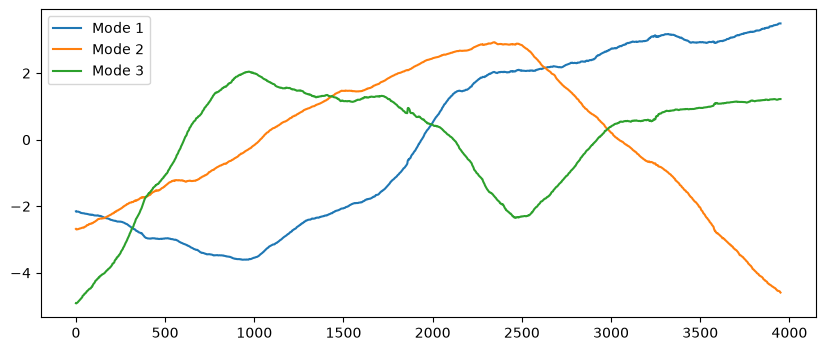

In [481]:
plt.figure(figsize=(10,4))
plt.plot(coords[:,0],label="Mode 1")
plt.plot(coords[:,1],label="Mode 2")
plt.plot(coords[:,2],label="Mode 3")
plt.legend()

Text(0, 0.5, 'Singular value')

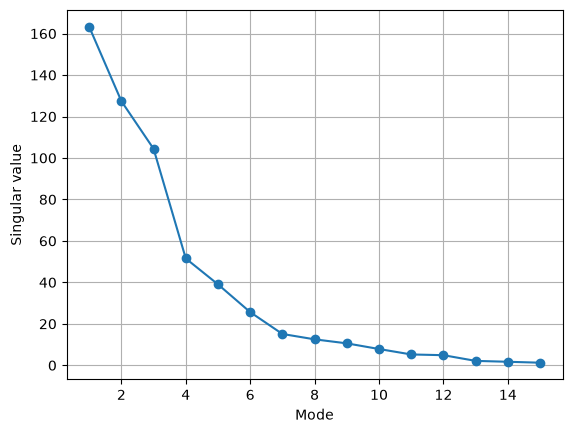

In [482]:
plt.plot(np.arange(1,S.shape[0]+1),S, 'o-')
plt.grid()
plt.xlabel("Mode")
plt.ylabel("Singular value")

In [483]:

from dataclasses import dataclass,field
from typing import Optional
from functools import cached_property
@dataclass
class SVDAnalysis:
    
    # Original data
    data: NDArray[np.float64]
    # SVD decomposition
    U: NDArray[np.float64]
    S: NDArray[np.float64]
    VT: NDArray[np.float64]
    
    # Metadata
    n_modes: int = 3
    
    # Low-dimensional representation
    @cached_property
    def scores(self)->NDArray[np.float64]:
        """
        Coordinates of the observations in the singular vector basis,
        computed as Z = UΣ.
        
        Returns:
            NDArray[np.float64]: _description_
        """
        return self.U @ np.diag(self.S)
       
    
    @cached_property
    def variance(self) -> NDArray[np.float64]:
        """Variance captured by each singular mode."""
        return self.S**2   
       
      
    @cached_property
    def coordinates(self)->NDArray[np.float64]:
        return self.scores[:,:self.n_modes]
    
    @cached_property
    def explained_variance_ratio(self) -> NDArray[np.float64]:
        """Fraction of total variance captured by each mode."""
        var = self.variance
        return var / var.sum()
    
    
    @cached_property
    def explained_variance(self)-> NDArray[np.float64]:
        return self.S**2 / np.sum(self.S**2)
        
    @cached_property
    def cumulative_variance(self)-> NDArray[np.float64]:
        return np.cumsum(self.explained_variance_ratio)
    
    @cached_property
    def reconstruct(self)-> NDArray[np.float64]:
        return (self.U[:,:self.n_modes] 
                @ np.diag(self.S[:self.n_modes])
                @ self.VT[:self.n_modes])
    
    @cached_property
    def reconstruction_error(self) -> float:
        return np.linalg.norm(
            self.data - self.reconstruct,
            ord="fro"
        )
    
    @cached_property
    def rank(self):
        return np.linalg.matrix_rank(self.data)
    
    
def compute_svd(pairmatrix:NDArray[np.float64],ndominant:int=3)->SVDAnalysis:
    U,S,VT = np.linalg.svd(pairmatrix,full_matrices=False)
    return SVDAnalysis(data = pairmatrix,U=U,S=S,VT=VT,n_modes=ndominant)



In [484]:
svd = compute_svd(pstandard)

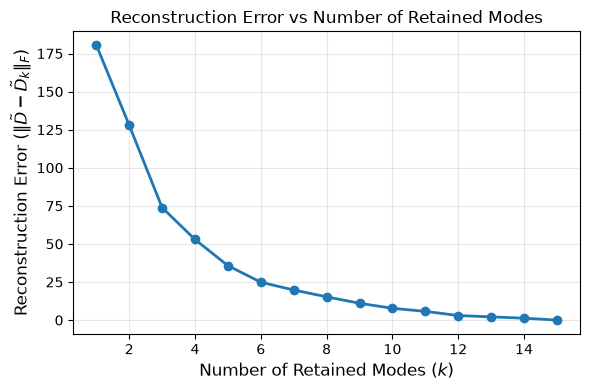

In [485]:
errors = []
ks = np.arange(1, len(svd.S) + 1)

for k in ks:
    Dk = (
        svd.U[:, :k]
        @ np.diag(svd.S[:k])
        @ svd.VT[:k, :]
    )

    err = np.linalg.norm(svd.data - Dk, ord='fro')
    errors.append(err)

plt.figure(figsize=(6,4))

plt.plot(ks, errors, 'o-', lw=2)

plt.xlabel('Number of Retained Modes ($k$)', fontsize=12)
plt.ylabel(r'Reconstruction Error ($\|\tilde{D}-\tilde{D}_k\|_F$)', fontsize=12)

plt.title('Reconstruction Error vs Number of Retained Modes')

plt.grid(alpha=0.3)

plt.tight_layout()

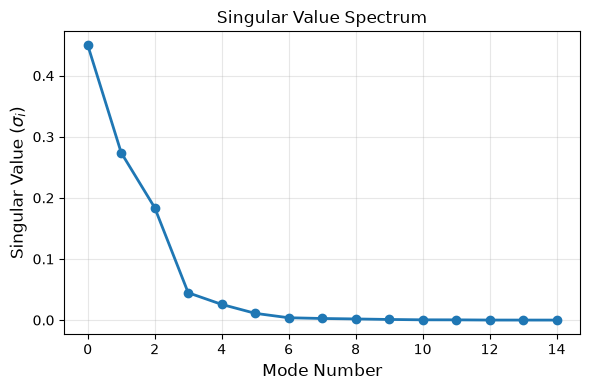

In [486]:
plt.figure(figsize=(6,4))

plt.plot(svd.explained_variance, 'o-', lw=2)

plt.xlabel('Mode Number', fontsize=12)
plt.ylabel(r'Singular Value ($\sigma_i$)', fontsize=12)

plt.title('Singular Value Spectrum')

plt.grid(alpha=0.3)
plt.tight_layout()


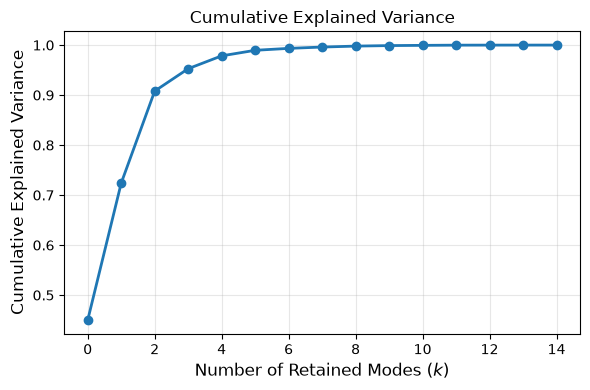

In [487]:
plt.figure(figsize=(6,4))

plt.plot(svd.cumulative_variance,'o-',lw=2)

plt.xlabel('Number of Retained Modes ($k$)',fontsize=12)

plt.ylabel('Cumulative Explained Variance',fontsize=12)

plt.title('Cumulative Explained Variance')

plt.grid(alpha=.3)

plt.tight_layout()


In [488]:
for i, (v, c) in enumerate(
        zip(svd.explained_variance_ratio,
            svd.cumulative_variance), start=1):
    print(
        f"{i} & {100*v:.2f} & {100*c:.2f}\\\\"
    )

1 & 45.01 & 45.01\\
2 & 27.39 & 72.40\\
3 & 18.40 & 90.80\\
4 & 4.48 & 95.28\\
5 & 2.57 & 97.85\\
6 & 1.11 & 98.96\\
7 & 0.38 & 99.34\\
8 & 0.26 & 99.61\\
9 & 0.19 & 99.80\\
10 & 0.10 & 99.90\\
11 & 0.05 & 99.94\\
12 & 0.04 & 99.98\\
13 & 0.01 & 99.99\\
14 & 0.00 & 100.00\\
15 & 0.00 & 100.00\\


In [489]:
from dataclasses import dataclass,field
from typing import Optional
from functools import cached_property
@dataclass
class SVDAnalysis:
    
    # Original data
    data: NDArray[np.float64]
    # SVD decomposition
    U: NDArray[np.float64]
    S: NDArray[np.float64]
    VT: NDArray[np.float64]
    
    # Metadata
    n_modes: int = 3
    
    # Low-dimensional representation
    @cached_property
    def scores(self)->NDArray[np.float64]:
        """scalar multiplication of vectors u with sigma eigenvalues  

        Returns:
            NDArray[np.float64]: _description_
        """
        return self.S * self.U 
         
    @cached_property
    def reduced_scores(self)->NDArray[np.float64]:
        return self.scores[:,:self.n_modes]
    
    @cached_property
    def explained_variance(self):
        return self.S**2 / np.sum(self.S**2)
        
    @cached_property
    def cumulative_variance(self):
        return np.cumsum(self.explained_variance)
    
    @cached_property
    def reconstruct(self):
        return (self.U[:,:self.n_modes] 
                @ np.diag(self.S[:self.n_modes])
                @ self.VT[:self.n_modes])
    
    
def compute_svd(pairmatrix:NDArray[np.float64],ndominant:int=3)->SVDAnalysis:
    U,S,VT = np.linalg.svd(pairmatrix,full_matrices=False)
    return SVDAnalysis(data = pairmatrix,U=U,S=S,VT=VT,n_modes=ndominant)

psvd = compute_svd(pstandard,ndominant=3)

In [490]:
trajectories,*_ = load_positions('../output_droplet_tracking/csv_files/for_2.1_droplets.csv')
p = compute_inter_distance_squared(trajectories=trajectories)
pstandard = p.standardized()
svd = compute_svd(pstandard)

In [491]:
svd.explained_variance

array([0.5437531 , 0.30220947, 0.11417791, 0.02538039, 0.01099784,
       0.00348129])

/tmp/ipykernel_2156/421043421.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


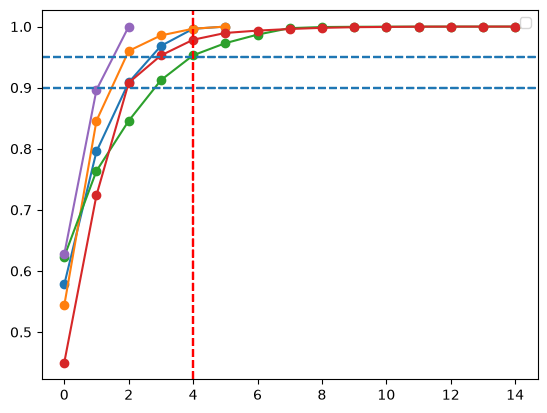

In [492]:
for idx,i in enumerate(os.listdir('../output_droplet_tracking/csv_files')):
    trajectories,*_ = load_positions(os.path.join('../output_droplet_tracking/csv_files',i))
    p = compute_inter_distance_squared(trajectories=trajectories)
    pstandard = p.standardized()
    svd = compute_svd(pstandard)
    # plt.scatter(np.arange(svd.explained_variance.shape[0]),svd.explained_variance,marker='.')
    # plt.plot(np.arange(svd.explained_variance.shape[0]),svd.explained_variance,label=f"{i}")
    cum = np.cumsum(svd.explained_variance)

    plt.plot(cum, 'o-')
    plt.axhline(0.90, ls='--')
    plt.axhline(0.95, ls='--')
    plt.axvline(4, ls='--',c='r')
    
plt.legend()

for dataset for_2&4ul_droplets.csv
[138.42622887  84.94912454  61.22160005  44.49690833  30.49855002
  10.93639258]
for dataset for_2.1_droplets.csv
[109.09476542  81.33117984  49.99126098  23.56960053  15.5151758
   8.72917063]
for dataset for_2.2_droplets.csv
[177.34143229  84.13124702  64.30624392  57.9440799   45.29446899
  31.69528364  26.5546446   23.09530387   9.61260237   4.50819253
   3.07960185   2.26233516   1.06956707   0.80970168   0.53898533]
for dataset for_2.3_droplets.csv
[163.32040581 127.41405501 104.4276841   51.51214304  39.02794631
  25.63805408  15.10099268  12.51588935  10.57557348   7.84458436
   5.22264658   4.86815892   2.12180177   1.6939364    1.24777328]
for dataset for_2.4_droplets.csv
[99.57145216 65.19014831 40.45702014]


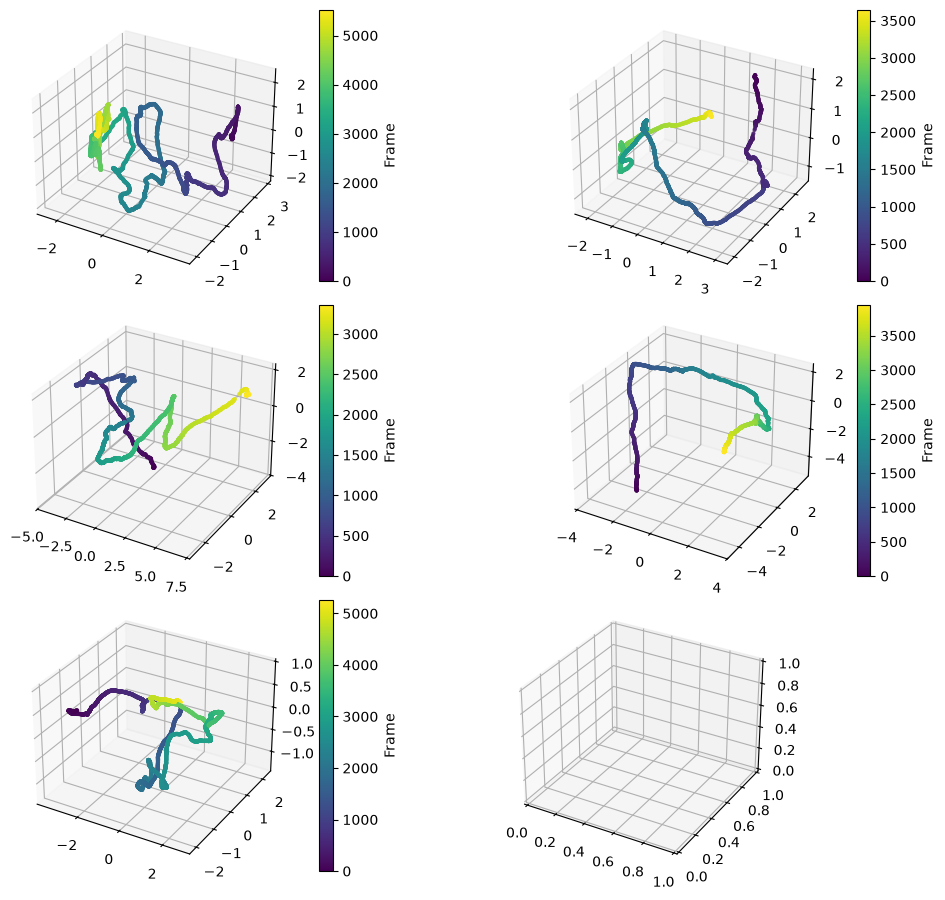

In [493]:


# fig = plt.figure(figsize=(8,6))
# ax = fig.add_subplot(projection="3d")
fig,ax = plt.subplots(3,2,subplot_kw={'projection': '3d'},figsize=(12,9))
ax = ax.flatten()


for idx,i in enumerate(os.listdir('../output_droplet_tracking/csv_files')):
    trajectories,*_ = load_positions(os.path.join('../output_droplet_tracking/csv_files',i))
    p = compute_inter_distance_squared(trajectories=trajectories)
    pstandard = p.standardized()
    svd = compute_svd(pstandard)
    
    print(f'for dataset {i}')
    print(svd.S)
    print(10*'=')
    
    t = np.arange(svd.reduced_scores.shape[0])  
    
    p = ax[idx].scatter(
        svd.reduced_scores[:,0],
        svd.reduced_scores[:,1],
        svd.reduced_scores[:,2],
        c=t,
        cmap="viridis",
        s=4
    )

    ax[idx].plot(svd.reduced_scores[:,0],
        svd.reduced_scores[:,1],
        svd.reduced_scores[:,2],
            color="gray", alpha=0.3)

    plt.colorbar(p,label="Frame")

plt.tight_layout()
# svd.reduced_scores

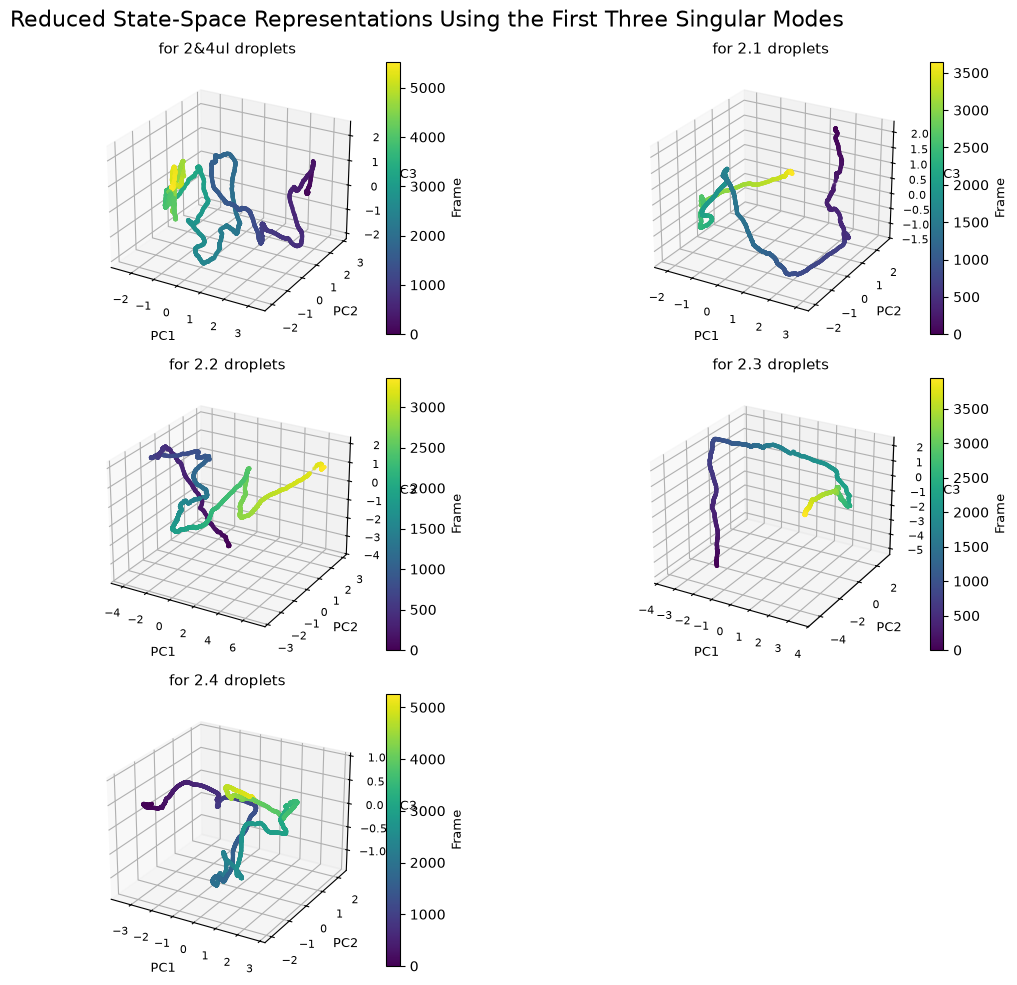

In [494]:
import os
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    3,
    2,
    figsize=(12, 10),
    subplot_kw={"projection": "3d"}
)

ax = ax.flatten()

csv_dir = "../output_droplet_tracking/csv_files"

for idx, file in enumerate(sorted(os.listdir(csv_dir))):

    trajectories, *_ = load_positions(os.path.join(csv_dir, file))

    p = compute_inter_distance_squared(trajectories)
    pstandard = p.standardized()

    svd = compute_svd(pstandard)

    coords = svd.reduced_scores

    t = np.arange(coords.shape[0])

    sc = ax[idx].scatter(
        coords[:,0],
        coords[:,1],
        coords[:,2],
        c=t,
        cmap="viridis",
        s=4
    )

    ax[idx].plot(
        coords[:,0],
        coords[:,1],
        coords[:,2],
        color="gray",
        alpha=0.35,
        lw=0.8
    )

    # ---------- subplot title ----------
    title = os.path.splitext(file)[0].replace("_", " ")
    ax[idx].set_title(title, fontsize=11)

    # ---------- axis labels ----------
    ax[idx].set_xlabel("PC1", fontsize=9)
    ax[idx].set_ylabel("PC2", fontsize=9)
    ax[idx].set_zlabel("PC3", fontsize=9)

    # ---------- viewing angle ----------
    ax[idx].view_init(elev=25, azim=-60)

    # ---------- tick size ----------
    ax[idx].tick_params(labelsize=8)

    # ---------- colorbar ----------
    cbar = fig.colorbar(
        sc,
        ax=ax[idx],
        fraction=0.046,
        pad=0.04
    )

    cbar.set_label("Frame", fontsize=9)

# Hide unused subplot
for i in range(len(os.listdir(csv_dir)), len(ax)):
    ax[i].axis("off")

fig.suptitle(
    "Reduced State-Space Representations Using the First Three Singular Modes",
    fontsize=16,
    y=0.98
)

plt.tight_layout()

plt.savefig(
    "Reduced_State_Space_All_Datasets.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

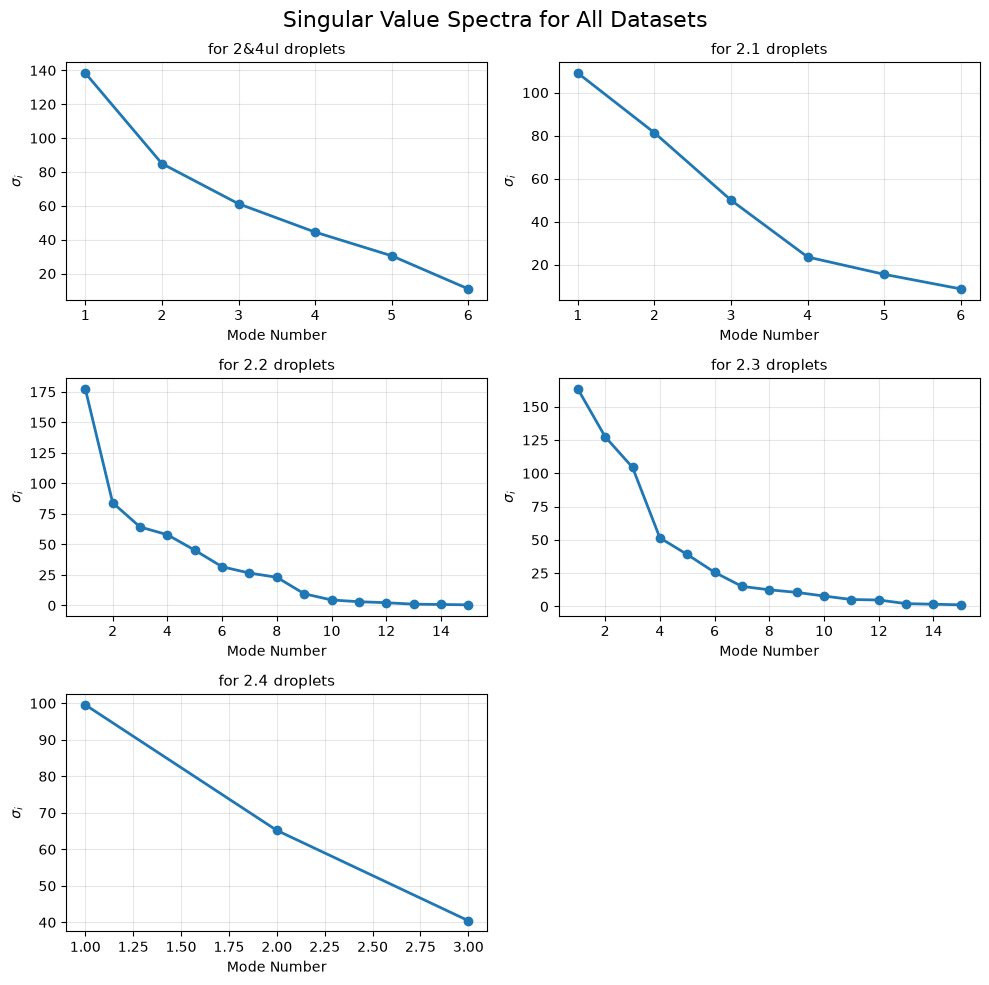

In [495]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))
ax = ax.flatten()

csv_dir = "../output_droplet_tracking/csv_files"

for idx, file in enumerate(sorted(os.listdir(csv_dir))):

    trajectories, *_ = load_positions(os.path.join(csv_dir, file))

    p = compute_inter_distance_squared(trajectories)
    pstandard = p.standardized()
    svd = compute_svd(pstandard)

    ax[idx].plot(
        np.arange(1, len(svd.S)+1),
        svd.S,
        'o-',
        lw=2
    )

    title = os.path.splitext(file)[0].replace("_", " ")

    ax[idx].set_title(title, fontsize=11)

    ax[idx].set_xlabel("Mode Number")
    ax[idx].set_ylabel(r"$\sigma_i$")

    ax[idx].grid(alpha=0.3)

for i in range(len(os.listdir(csv_dir)), len(ax)):
    ax[i].axis("off")

fig.suptitle(
    "Singular Value Spectra for All Datasets",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "Singular_Value_Spectrum_All.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

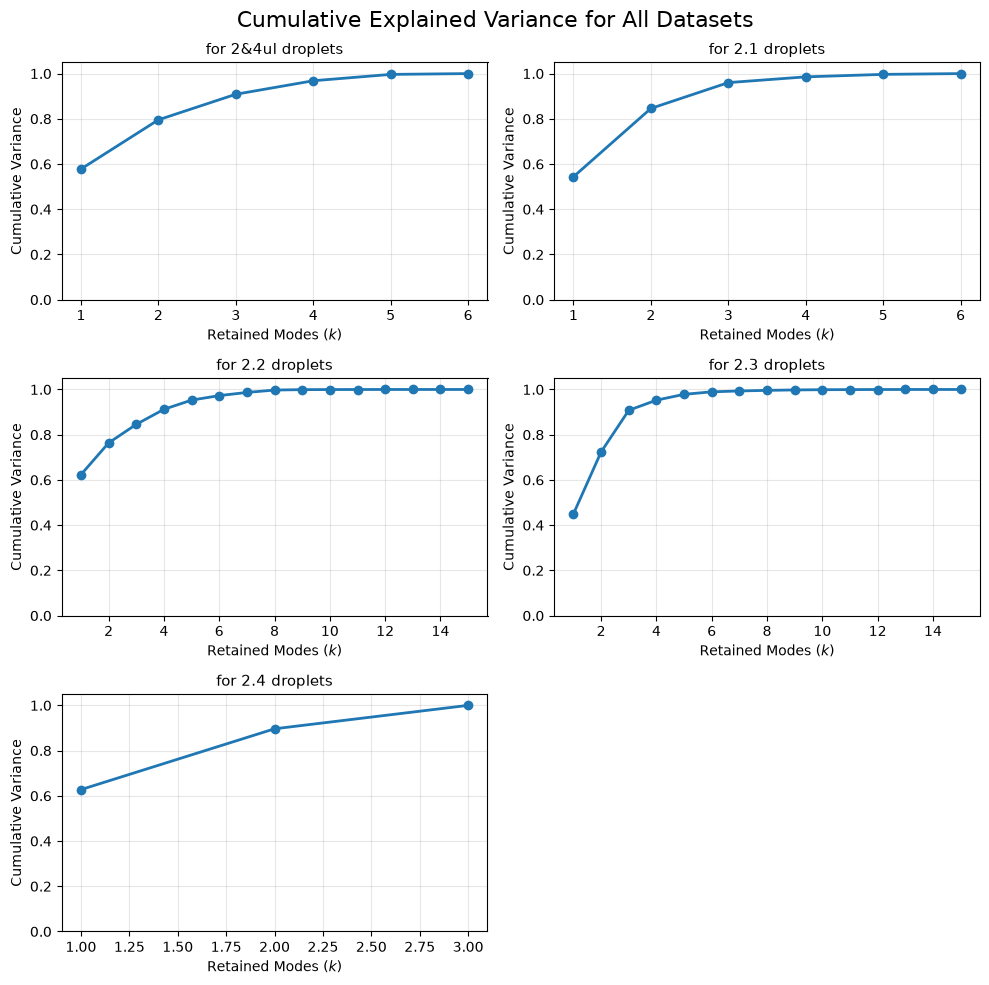

In [496]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))
ax = ax.flatten()

csv_dir = "../output_droplet_tracking/csv_files"

for idx, file in enumerate(sorted(os.listdir(csv_dir))):

    trajectories, *_ = load_positions(os.path.join(csv_dir, file))

    p = compute_inter_distance_squared(trajectories)
    pstandard = p.standardized()

    svd = compute_svd(pstandard)

    ax[idx].plot(
        np.arange(1, len(svd.S)+1),
        svd.cumulative_variance,
        'o-',
        lw=2
    )

    title = os.path.splitext(file)[0].replace("_", " ")

    ax[idx].set_title(title, fontsize=11)

    ax[idx].set_xlabel("Retained Modes ($k$)")
    ax[idx].set_ylabel("Cumulative Variance")

    ax[idx].set_ylim(0,1.05)

    ax[idx].grid(alpha=0.3)

for i in range(len(os.listdir(csv_dir)), len(ax)):
    ax[i].axis("off")

fig.suptitle(
    "Cumulative Explained Variance for All Datasets",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "Cumulative_Explained_Variance_All.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

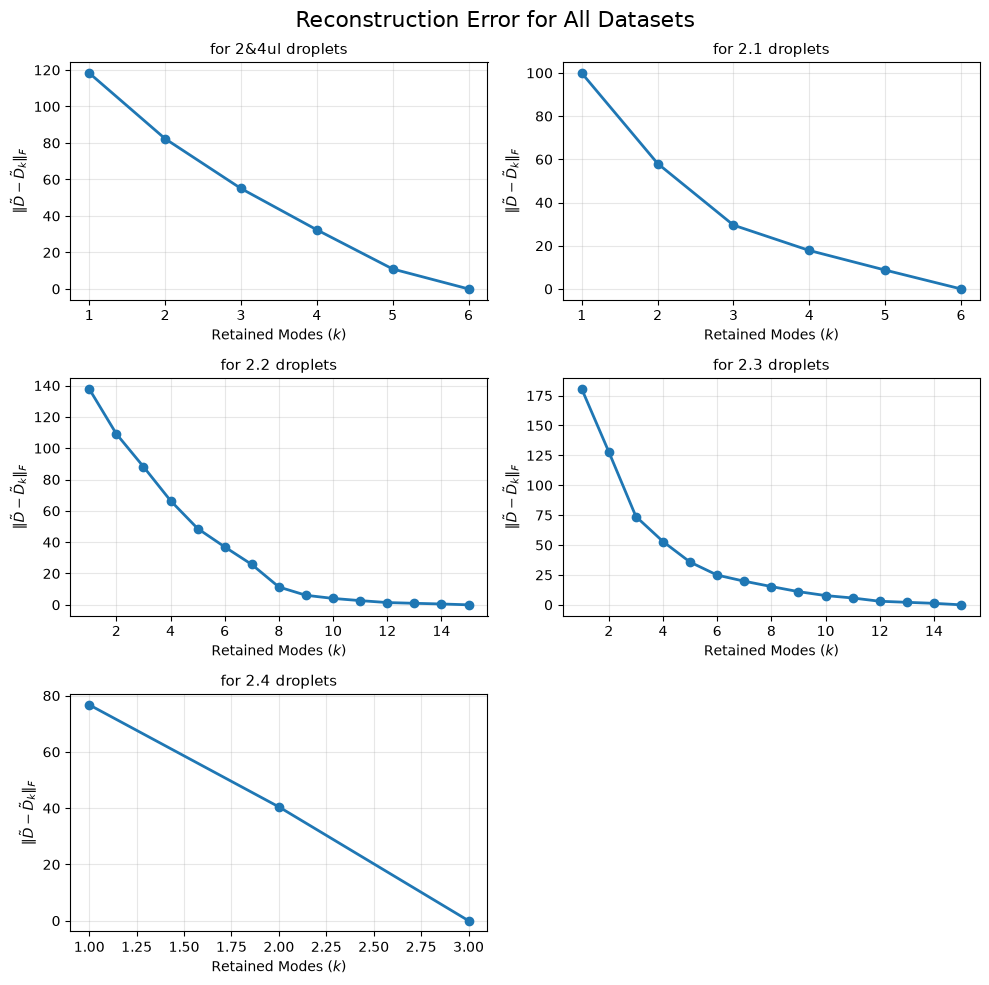

In [497]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))
ax = ax.flatten()

csv_dir = "../output_droplet_tracking/csv_files"

for idx, file in enumerate(sorted(os.listdir(csv_dir))):

    trajectories, *_ = load_positions(os.path.join(csv_dir, file))

    p = compute_inter_distance_squared(trajectories)
    pstandard = p.standardized()

    svd = compute_svd(pstandard)

    errors = []

    ks = np.arange(1, len(svd.S)+1)

    for k in ks:

        Dk = (
            svd.U[:, :k]
            @ np.diag(svd.S[:k])
            @ svd.VT[:k]
        )

        errors.append(
            np.linalg.norm(
                svd.data - Dk,
                ord='fro'
            )
        )

    ax[idx].plot(
        ks,
        errors,
        'o-',
        lw=2
    )

    title = os.path.splitext(file)[0].replace("_", " ")

    ax[idx].set_title(title, fontsize=11)

    ax[idx].set_xlabel("Retained Modes ($k$)")
    ax[idx].set_ylabel(r"$\|\tilde D-\tilde D_k\|_F$")

    ax[idx].grid(alpha=0.3)

for i in range(len(os.listdir(csv_dir)), len(ax)):
    ax[i].axis("off")

fig.suptitle(
    "Reconstruction Error for All Datasets",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "Reconstruction_Error_All.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [503]:
rows = []
csv_dir = "../output_droplet_tracking/csv_files"

for file in sorted(os.listdir(csv_dir)):

    # ---------------- Load dataset ----------------
    trajectories, *_ = load_positions(os.path.join(csv_dir, file))

    p = compute_inter_distance_squared(trajectories)
    pstandard = p.standardized()

    svd = compute_svd(pstandard)

    # ---------------- Dataset information ----------------
    dataset = os.path.splitext(file)[0]

    n_frames = pstandard.shape[0]
    n_pairs = pstandard.shape[1]
    rank = len(svd.S)

    # Number of droplets
    # P = M(M-1)/2
    M = int((1 + np.sqrt(1 + 8*n_pairs))/2)

    # ---------------- Explained variance ----------------
    var3 = 100 * svd.cumulative_variance[2]

    if rank >= 4:
        var4 = 100 * svd.cumulative_variance[3]
    else:
        var4 = np.nan

    # Modes required for 90% and 95%
    modes90 = np.argmax(svd.cumulative_variance >= 0.90) + 1
    modes95 = np.argmax(svd.cumulative_variance >= 0.95) + 1

    rows.append({
        "Dataset": dataset,
        "Frames": n_frames,
        "Droplets": M,
        "Pairs": n_pairs,
        "Rank": rank,
        "Variance (3 Modes) [%]": round(var3, 2),
        "Variance (4 Modes) [%]": round(var4, 2),
        "Modes for 90%": modes90,
        "Modes for 95%": modes95,
    })

summary = pd.DataFrame(rows)
print(summary.to_latex(
    index=False,
    float_format="%.2f",
    column_format="lrrrrrrrr",
    caption="Summary of the SVD analysis for all datasets.",
    label="tab:svd_summary"
))
# print(summary)

\begin{table}
\caption{Summary of the SVD analysis for all datasets.}
\label{tab:svd_summary}
\begin{tabular}{lrrrrrrrr}
\toprule
Dataset & Frames & Droplets & Pairs & Rank & Variance (3 Modes) [%] & Variance (4 Modes) [%] & Modes for 90% & Modes for 95% \\
\midrule
for_2&4ul_droplets & 5526 & 4 & 6 & 6 & 90.86 & 96.83 & 3 & 4 \\
for_2.1_droplets & 3648 & 4 & 6 & 6 & 96.01 & 98.55 & 3 & 3 \\
for_2.2_droplets & 3363 & 6 & 15 & 15 & 84.57 & 91.23 & 4 & 5 \\
for_2.3_droplets & 3951 & 6 & 15 & 15 & 90.80 & 95.28 & 3 & 4 \\
for_2.4_droplets & 5267 & 3 & 3 & 3 & 100.00 & NaN & 3 & 3 \\
\bottomrule
\end{tabular}
\end{table}

